# Potential Settings

`generate_potential` accepts a keyword argument that controls the generated LAMMPS script:

| Parameter | Type | Default | Effect |
|-----------|------|---------|--------|
| `electrostatics` | `DsfConfig \| WolfConfig \| PppmConfig \| EwaldConfig \| None` | `None` → potential default | Coulomb solver, cutoffs, and damping |

This notebook shows how the setting changes the LAMMPS input and covers all three potentials.

In [1]:
from IPython.display import display as ipydisplay, Math
import amorphouspy as am
from amorphouspy.lammps.potentials.potential import (
    generate_potential,
    DsfConfig,
    WolfConfig,
    PppmConfig,
    EwaldConfig,
)


def print_lammps_script(potential):
    """Print the LAMMPS input lines from a potential DataFrame."""
    print("".join(potential["Config"].iloc[0]))

## Setup — build a structure dictionary

The potential generators only need the composition and atom counts from `get_structure_dict` — no simulation is run here.

In [2]:
# Na2O-SiO2 glass (25 mol% Na2O) — supported by PMMCS and SHIK
nss_dict = am.get_structure_dict({"Na2O": 0.25, "SiO2": 0.75}, target_atoms=200)

# CaO-Al2O3-SiO2 glass — supported by PMMCS, BJP, and SHIK
cas_dict = am.get_structure_dict({"CaO": 0.25, "Al2O3": 0.25, "SiO2": 0.50}, target_atoms=200)

## PMMCS potential

PMMCS (Pedone) uses a Morse pair style (`pedone`) with a hybrid Coulomb solver. It supports all four electrostatic methods and covers 29 elements. The default Coulomb method is DSF with `alpha=0.25` Å⁻¹ and a cutoff of 8.0 Å.

### Default (DSF, α = 0.25, cutoff = 8.0 Å)

In [3]:
potential_pmmcs_default = generate_potential(nss_dict, potential_type="pmmcs")
print_lammps_script(potential_pmmcs_default)

# A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018
units metal
dimension 3
atom_style charge

# create groups ###
group Na type 1
group O type 2
group Si type 3

### set charges ###
set type 1 charge 0.6
set type 2 charge -1.2
set type 3 charge 2.4

### Pmmcs Potential Parameters ###
pair_style hybrid/overlay coul/dsf 0.25 8.0 pedone 5.5
pair_coeff * * coul/dsf
pair_coeff 1 2 pedone 0.023363 1.763867 3.006315 5.0
pair_coeff 2 2 pedone 0.042395 1.379316 3.618701 22.0
pair_coeff 3 2 pedone 0.340554 2.0067 2.1 1.0

pair_modify shift yes



### DSF with custom α and cutoff

`DsfConfig` lets you tune the damping parameter `alpha` (Å⁻¹) and the Coulomb cutoff `long_range_cutoff` (Å). Both are optional — omit either to keep the potential default.

In [4]:
cfg = DsfConfig(alpha=0.3, long_range_cutoff=9.0)
potential_pmmcs_dsf = generate_potential(nss_dict, potential_type="pmmcs", electrostatics=cfg)
print_lammps_script(potential_pmmcs_dsf)

# A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018
units metal
dimension 3
atom_style charge

# create groups ###
group Na type 1
group O type 2
group Si type 3

### set charges ###
set type 1 charge 0.6
set type 2 charge -1.2
set type 3 charge 2.4

### Pmmcs Potential Parameters ###
pair_style hybrid/overlay coul/dsf 0.3 9.0 pedone 5.5
pair_coeff * * coul/dsf
pair_coeff 1 2 pedone 0.023363 1.763867 3.006315 5.0
pair_coeff 2 2 pedone 0.042395 1.379316 3.618701 22.0
pair_coeff 3 2 pedone 0.340554 2.0067 2.1 1.0

pair_modify shift yes



### Wolf summation

`WolfConfig` has the same parameters as `DsfConfig` but uses the Wolf damped Coulomb method instead.

In [5]:
cfg = WolfConfig(alpha=0.25, long_range_cutoff=8.0)
potential_pmmcs_wolf = generate_potential(nss_dict, potential_type="pmmcs", electrostatics=cfg)
print_lammps_script(potential_pmmcs_wolf)

# A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018
units metal
dimension 3
atom_style charge

# create groups ###
group Na type 1
group O type 2
group Si type 3

### set charges ###
set type 1 charge 0.6
set type 2 charge -1.2
set type 3 charge 2.4

### Pmmcs Potential Parameters ###
pair_style hybrid/overlay coul/wolf 0.25 8.0 pedone 5.5
pair_coeff * * coul/wolf
pair_coeff 1 2 pedone 0.023363 1.763867 3.006315 5.0
pair_coeff 2 2 pedone 0.042395 1.379316 3.618701 22.0
pair_coeff 3 2 pedone 0.340554 2.0067 2.1 1.0

pair_modify shift yes



### Choosing α — the α·r_c = 2 rule

Both DSF and Wolf damp the Coulomb interaction with the complementary error function. At the cutoff $r_c$ the pair energy is multiplied by $\operatorname{erfc}(\alpha r_c)$. The truncation error is proportional to this residual, so the goal is to push it close to zero before cutting. The standard rule of thumb is $\alpha \cdot r_c \approx 2$, giving $\operatorname{erfc}(2) \approx 0.0047$ — less than 0.5 % of the bare $1/r$ value survives at the cutoff.

In [6]:
ipydisplay(Math(r"\phi(r) = \frac{q_i q_j \operatorname{erfc}(\alpha r)}{r}"))
ipydisplay(Math(r"\alpha \cdot r_c \approx 2 \quad \Longrightarrow \quad \operatorname{erfc}(2) \approx 0.0047"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

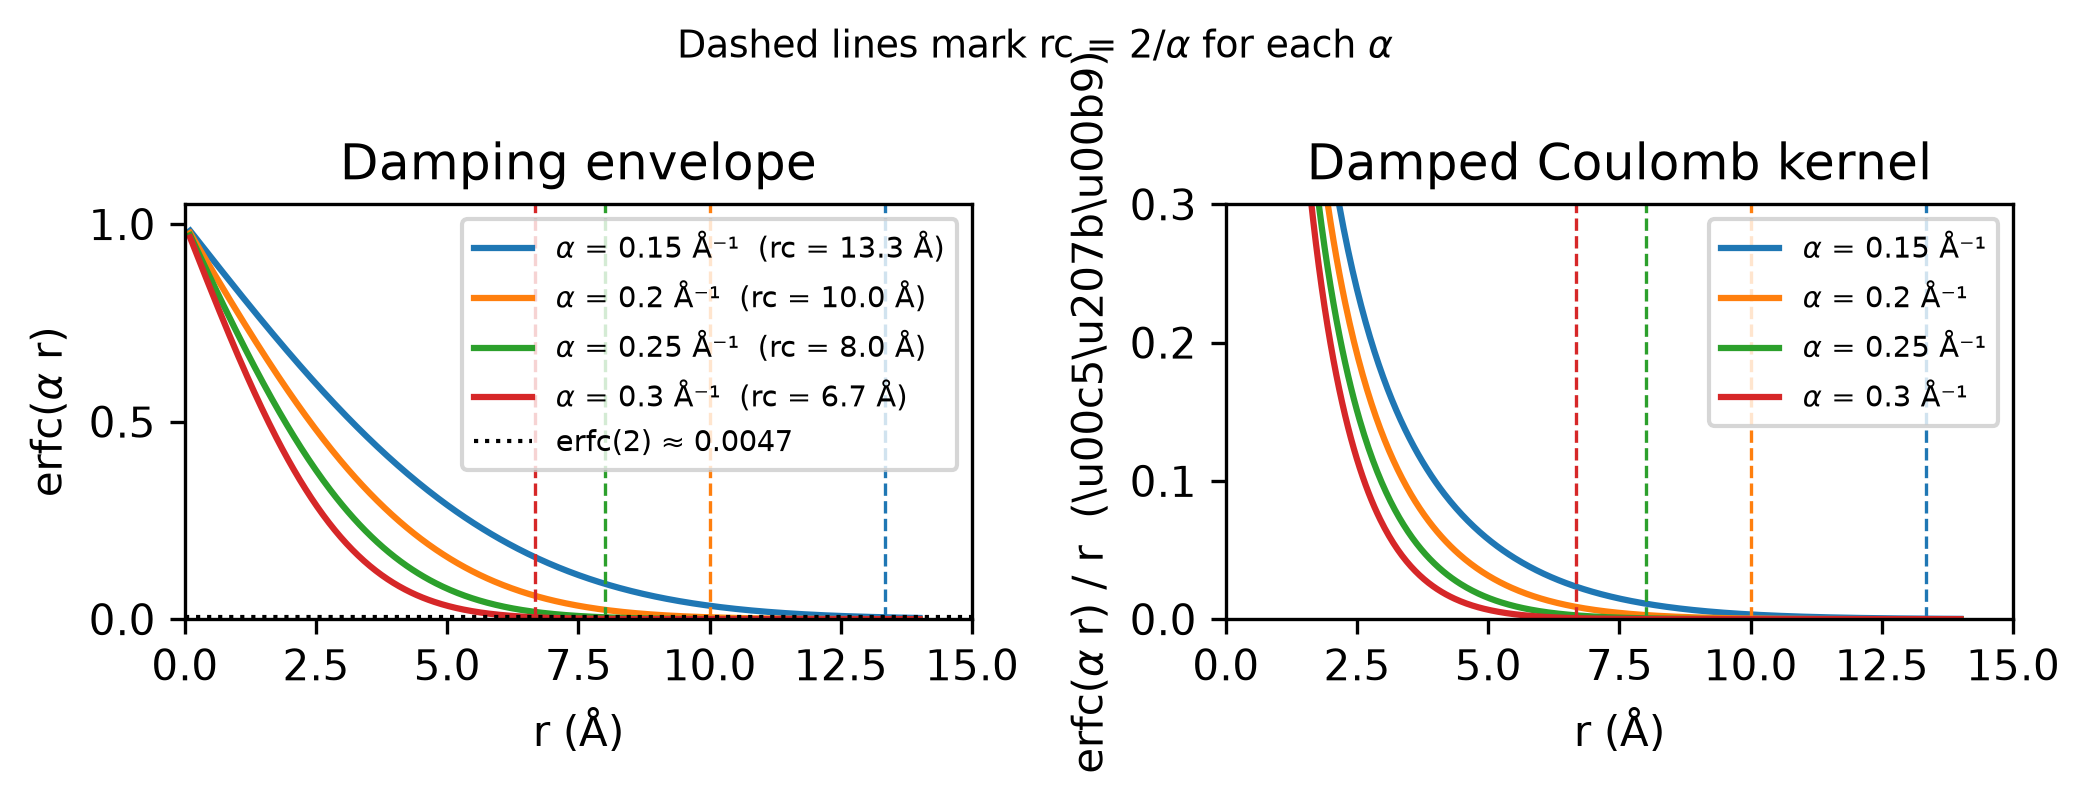

<IPython.core.display.Math object>

  α = 0.15 Å⁻¹,  rc = 13.3 Å  →  erfc(2) = 0.00468
  α = 0.20 Å⁻¹,  rc = 10.0 Å  →  erfc(2) = 0.00468
  α = 0.25 Å⁻¹,  rc = 8.0 Å  →  erfc(2) = 0.00468
  α = 0.30 Å⁻¹,  rc = 6.7 Å  →  erfc(2) = 0.00468


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

r = np.linspace(0.1, 14, 500)
alphas = [0.15, 0.20, 0.25, 0.30]
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5 / 1.333), dpi=300)

for alpha, color in zip(alphas, colors):
    rc = 2.0 / alpha  # cutoff satisfying alpha*rc = 2
    axes[0].plot(
        r, erfc(alpha * r), color=color, label=f"$\\alpha$ = {alpha} \u00c5\u207b\u00b9  (rc = {rc:.1f} \u00c5)"
    )
    axes[0].axvline(rc, color=color, ls="--", lw=0.8)
    axes[1].plot(r, erfc(alpha * r) / r, color=color, label=f"$\\alpha$ = {alpha} \u00c5\u207b\u00b9")
    axes[1].axvline(rc, color=color, ls="--", lw=0.8)

axes[0].axhline(erfc(2), color="black", ls=":", lw=1, label=f"erfc(2) \u2248 {erfc(2):.4f}")
axes[0].set_xlabel("r (\u00c5)")
axes[0].set_ylabel(r"erfc($\alpha$ r)")
axes[0].set_title("Damping envelope")
axes[0].legend(fontsize=7)
axes[0].set_xlim(0, 15)
axes[0].set_ylim(0, 1.05)

axes[1].set_xlabel("r (\u00c5)")
axes[1].set_ylabel(r"erfc($\alpha$ r) / r  (\u00c5\u207b\u00b9)")
axes[1].set_title("Damped Coulomb kernel")
axes[1].set_xlim(0, 15)
axes[1].set_ylim(0, 0.3)
axes[1].legend(fontsize=7)

fig.suptitle(r"Dashed lines mark rc = 2/$\alpha$ for each $\alpha$", fontsize=9)
plt.tight_layout()
plt.show()

ipydisplay(Math(r"\text{Residual } \operatorname{erfc}(\alpha r_c)\ \text{at}\ r_c=\frac{2}{\alpha}"))
for alpha in alphas:
    rc = 2.0 / alpha
    print(f"  \u03b1 = {alpha:.2f} \u00c5\u207b\u00b9,  rc = {rc:.1f} \u00c5  \u2192  erfc(2) = {erfc(2):.5f}")

All four curves reach the same residual at their respective cutoffs, the cutoff scales inversely with α while the accuracy at the cutoff stays fixed at erfc(2) ≈ 0.0047.

In practice:
- **Larger α** damps faster → shorter cutoff, cheaper run, but larger self-energy correction
- **Smaller α** damps slower → longer cutoff needed, smoother convergence
- The potentials here were parameterised with specific (α, r_c) pairs that all satisfy α·r_c = 2: PMMCS/BJP use α = 0.25 Å⁻¹ / r_c = 8.0 Å; SHIK uses α = 0.2 Å⁻¹ / r_c = 10.0 Å
- If you change the cutoff, scale α to keep α·r_c ≈ 2

### PPPM (reciprocal-space)

`PppmConfig` activates the particle–particle particle–mesh Ewald solver. There is no `alpha` — the damping is handled internally by LAMMPS. `kspace_accuracy` sets the relative precision of the reciprocal-space sum.

In [8]:
cfg = PppmConfig(long_range_cutoff=12.0, kspace_accuracy=1e-5)
potential_pmmcs_pppm = generate_potential(nss_dict, potential_type="pmmcs", electrostatics=cfg)
print_lammps_script(potential_pmmcs_pppm)

# A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018
units metal
dimension 3
atom_style charge

# create groups ###
group Na type 1
group O type 2
group Si type 3

### set charges ###
set type 1 charge 0.6
set type 2 charge -1.2
set type 3 charge 2.4

### Pmmcs Potential Parameters ###
pair_style hybrid/overlay coul/long 12.0 pedone 5.5
pair_coeff * * coul/long
kspace_style pppm 1e-05pair_coeff 1 2 pedone 0.023363 1.763867 3.006315 5.0
pair_coeff 2 2 pedone 0.042395 1.379316 3.618701 22.0
pair_coeff 3 2 pedone 0.340554 2.0067 2.1 1.0

pair_modify shift yes



### Ewald summation

`EwaldConfig` uses direct Ewald summation. Same parameters as `PppmConfig`; slower but sometimes preferred for small cells or debugging.

In [9]:
cfg = EwaldConfig(long_range_cutoff=12.0, kspace_accuracy=1e-6)
potential_pmmcs_ewald = generate_potential(nss_dict, potential_type="pmmcs", electrostatics=cfg)
print_lammps_script(potential_pmmcs_ewald)

# A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018
units metal
dimension 3
atom_style charge

# create groups ###
group Na type 1
group O type 2
group Si type 3

### set charges ###
set type 1 charge 0.6
set type 2 charge -1.2
set type 3 charge 2.4

### Pmmcs Potential Parameters ###
pair_style hybrid/overlay coul/long 12.0 pedone 5.5
pair_coeff * * coul/long
kspace_style ewald 1e-06pair_coeff 1 2 pedone 0.023363 1.763867 3.006315 5.0
pair_coeff 2 2 pedone 0.042395 1.379316 3.618701 22.0
pair_coeff 3 2 pedone 0.340554 2.0067 2.1 1.0

pair_modify shift yes



## BJP potential

BJP (Bouhadja) uses a Born-Mayer-Huggins pair style and is limited to the CaO-Al₂O₃-SiO₂ system. It supports all four electrostatic methods. The default is also DSF with `alpha=0.25` and cutoff 8.0 Å.

In [10]:
# Default BJP
potential_bjp_default = generate_potential(cas_dict, potential_type="bjp")
print_lammps_script(potential_bjp_default)

# Bouhadja et al., J. Chem. Phys. 138, 224510 (2013) 
units metal
dimension 3
atom_style charge

# create groups ###
group Al type 1
group Ca type 2
group O type 3
group Si type 4

### set charges ###
set type 1 charge 1.8
set type 2 charge 1.2
set type 3 charge -1.2
set type 4 charge 2.4

### Bouhadja Born-Mayer-Huggins + Coulomb Potential Parameters ###
pair_style born/coul/dsf 0.25 8.0
pair_coeff 1 1 0.002900 0.068000 1.570400 14.049800 0.000000
pair_coeff 1 2 0.003200 0.074000 1.957200 17.171000 0.000000
pair_coeff 1 3 0.007500 0.164000 2.606700 34.574700 0.000000
pair_coeff 1 4 0.002500 0.057000 1.505600 18.811600 0.000000
pair_coeff 2 2 0.003500 0.080000 2.344000 20.985600 0.000000
pair_coeff 2 3 0.007700 0.178000 2.993500 42.255600 0.000000
pair_coeff 2 4 0.002700 0.063000 1.892400 22.990700 0.000000
pair_coeff 3 3 0.012000 0.263000 3.643000 85.084000 0.000000
pair_coeff 3 4 0.007000 0.156000 2.541900 46.293000 0.000000
pair_coeff 4 4 0.001200 0.046000 1.440800 25.187300 0.00000

In [11]:
# BJP with PPPM
cfg = PppmConfig(long_range_cutoff=12.0)
potential_bjp_pppm = generate_potential(cas_dict, potential_type="bjp", electrostatics=cfg)
print_lammps_script(potential_bjp_pppm)

# Bouhadja et al., J. Chem. Phys. 138, 224510 (2013) 
units metal
dimension 3
atom_style charge

# create groups ###
group Al type 1
group Ca type 2
group O type 3
group Si type 4

### set charges ###
set type 1 charge 1.8
set type 2 charge 1.2
set type 3 charge -1.2
set type 4 charge 2.4

### Bouhadja Born-Mayer-Huggins + Coulomb Potential Parameters ###
pair_style born/coul/long 12.0
kspace_style pppm 1e-05pair_coeff 1 1 0.002900 0.068000 1.570400 14.049800 0.000000
pair_coeff 1 2 0.003200 0.074000 1.957200 17.171000 0.000000
pair_coeff 1 3 0.007500 0.164000 2.606700 34.574700 0.000000
pair_coeff 1 4 0.002500 0.057000 1.505600 18.811600 0.000000
pair_coeff 2 2 0.003500 0.080000 2.344000 20.985600 0.000000
pair_coeff 2 3 0.007700 0.178000 2.993500 42.255600 0.000000
pair_coeff 2 4 0.002700 0.063000 1.892400 22.990700 0.000000
pair_coeff 3 3 0.012000 0.263000 3.643000 85.084000 0.000000
pair_coeff 3 4 0.007000 0.156000 2.541900 46.293000 0.000000
pair_coeff 4 4 0.001200 0.046000 1.4408

## SHIK potential

SHIK (Sundararaman) uses a tabulated Buckingham + r⁻²⁴ pair potential and **only supports DSF** — any other method raises `ValueError`. The default is DSF with `alpha=0.2` Å⁻¹ and a cutoff of 10.0 Å, reflecting the original parameterization.

SHIK writes tabulated pair potential files to `"shik_tables"` by default.

In [12]:
# SHIK — default DSF (alpha=0.2, cutoff=10.0 Å)
potential_shik_default = generate_potential(nss_dict, potential_type="shik")
print_lammps_script(potential_shik_default)

# S. Sundararaman et al.,
# for silica glass, J. Chem. Phys. 2018, 148, 19, https://doi.org/10.1063/1.5023707
# for alkali and alkaline-earth aluminosilicate glasses, J. Chem. Phys. 2019, 150, 15, https://doi.org/10.1063/1.5079663
# for borate glasses with mixed network formers, J. Chem. Phys. 2020, 152, 10, https://doi.org/10.1063/1.5142605
# for alkaline earth silicate and borate glasses, Shih et al. J. Non-Cryst. Sol. 2021, 565, 120853, https://doi.org/10.1016/j.jnoncrysol.2021.120853

dimension 3
atom_style charge


### Group Definitions ###
group Na type 1
group O type 2
group Si type 3

### Charges ###
set type 1 charge 0.6018
set type 2 charge -0.9336427350427351
set type 3 charge 1.7755

### SHIK Potential ###
pair_style hybrid/overlay coul/dsf 0.2 10.0 table spline 10000
pair_coeff * * coul/dsf
pair_coeff 1 1 table "/Users/achrafatila/Documents/Workflows/amorphouspy/notebooks/shik_tables/table_Na_Na.tbl" SHIK_Buck_r24 8.0
pair_coeff 1 2 table "/Users/achrafatila/Documents/Work

In [13]:
# SHIK — custom DSF cutoff
cfg = DsfConfig(alpha=0.2, long_range_cutoff=12.0)
potential_shik_dsf = generate_potential(nss_dict, potential_type="shik", electrostatics=cfg)
print_lammps_script(potential_shik_dsf)

# S. Sundararaman et al.,
# for silica glass, J. Chem. Phys. 2018, 148, 19, https://doi.org/10.1063/1.5023707
# for alkali and alkaline-earth aluminosilicate glasses, J. Chem. Phys. 2019, 150, 15, https://doi.org/10.1063/1.5079663
# for borate glasses with mixed network formers, J. Chem. Phys. 2020, 152, 10, https://doi.org/10.1063/1.5142605
# for alkaline earth silicate and borate glasses, Shih et al. J. Non-Cryst. Sol. 2021, 565, 120853, https://doi.org/10.1016/j.jnoncrysol.2021.120853

dimension 3
atom_style charge


### Group Definitions ###
group Na type 1
group O type 2
group Si type 3

### Charges ###
set type 1 charge 0.6018
set type 2 charge -0.9336427350427351
set type 3 charge 1.7755

### SHIK Potential ###
pair_style hybrid/overlay coul/dsf 0.2 12.0 table spline 10000
pair_coeff * * coul/dsf
pair_coeff 1 1 table "/Users/achrafatila/Documents/Workflows/amorphouspy/notebooks/shik_tables/table_Na_Na.tbl" SHIK_Buck_r24 8.0
pair_coeff 1 2 table "/Users/achrafatila/Documents/Work

## Pre-equilibration for melt-quench runs

Generated potentials are pure force-field descriptions — they contain no MD run commands. The Langevin NVE/limit pre-equilibration needed for randomly placed structures is run by the melt-quench protocol itself as its own stage 0, at the melt temperature. It is on by default; pass `pre_equilibrate=False` to `run_melt_quench` / `melt_quench_simulation` when starting from an already-equilibrated structure.

In [14]:
# The generated script contains only force-field setup — no run commands
print_lammps_script(generate_potential(nss_dict, potential_type="pmmcs"))

# A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018
units metal
dimension 3
atom_style charge

# create groups ###
group Na type 1
group O type 2
group Si type 3

### set charges ###
set type 1 charge 0.6
set type 2 charge -1.2
set type 3 charge 2.4

### Pmmcs Potential Parameters ###
pair_style hybrid/overlay coul/dsf 0.25 8.0 pedone 5.5
pair_coeff * * coul/dsf
pair_coeff 1 2 pedone 0.023363 1.763867 3.006315 5.0
pair_coeff 2 2 pedone 0.042395 1.379316 3.618701 22.0
pair_coeff 3 2 pedone 0.340554 2.0067 2.1 1.0

pair_modify shift yes



## Quick reference

### Electrostatics config fields

| Config | `alpha` (Å⁻¹) | `long_range_cutoff` (Å) | `kspace_accuracy` | PMMCS | BJP | SHIK |
|--------|---------------|------------------------|-------------------|-------|-----|------|
| `DsfConfig` | optional | optional | — | ✓ | ✓ | ✓ |
| `WolfConfig` | optional | optional | — | ✓ | ✓ | ✗ |
| `PppmConfig` | — | optional | default 1e-5 | ✓ | ✓ | ✗ |
| `EwaldConfig` | — | optional | default 1e-5 | ✓ | ✓ | ✗ |

### Potential defaults

| Potential | Default method | Default α (Å⁻¹) | Default cutoff (Å) |
|-----------|---------------|-----------------|--------------------|
| PMMCS | DSF | 0.25 | 8.0 |
| BJP | DSF | 0.25 | 8.0 |
| SHIK | DSF | 0.2 | 10.0 |

The melt-quench pre-equilibration block is handled by the protocol (`pre_equilibrate=True` by default), not by `generate_potential`.